# 02 - Superficie de respuesta: optimizar el proceso

Tras el screening quedaron **3 factores activos**. Ahora queremos **maximizar el
rendimiento** modelando la curvatura de la respuesta con un modelo cuadratico completo.

Usamos un diseno de **Box-Behnken**, que estima terminos lineales, de interaccion y
cuadraticos sin ir a los vertices extremos del espacio (util cuando las condiciones
extremas son costosas o inseguras). Trabajamos en **unidades naturales** gracias a la
codificacion de factores.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import doekit as ed

rng = np.random.default_rng(3)
plt.rcParams["figure.figsize"] = (7, 4)

## 1. El diseno en unidades naturales

Definimos rangos reales por factor. El `Design` guarda la matriz ya **decodificada**:
temperatura en grados, pH en unidades de pH, concentracion en mol/L.

In [2]:
factors = {"temp": (30, 42), "pH": (6.0, 8.0), "sust": (5.0, 25.0)}
bb = ed.box_behnken(factors, center=3)
print(bb)
bb.matrix.round(3)

BoxBehnken
Dimension: (15, 3)
Factors: ['temp', 'pH', 'sust']
Model: Model(0 ~ (Intercept) + temp + pH + sust + temp:pH + temp:sust + pH:sust + temp^2 + pH^2 + sust^2)
Design Matrix:
    temp   pH  sust
0   30.0  6.0  15.0
1   42.0  6.0  15.0
2   30.0  8.0  15.0
3   42.0  8.0  15.0
4   30.0  7.0   5.0
5   42.0  7.0   5.0
6   30.0  7.0  25.0
7   42.0  7.0  25.0
8   36.0  6.0   5.0
9   36.0  8.0   5.0
10  36.0  6.0  25.0
11  36.0  8.0  25.0
12  36.0  7.0  15.0
13  36.0  7.0  15.0
14  36.0  7.0  15.0


,temp,pH,sust
0,30.0,6.0,15.0
1,42.0,6.0,15.0
2,30.0,8.0,15.0
3,42.0,8.0,15.0
4,30.0,7.0,5.0
5,42.0,7.0,5.0
6,30.0,7.0,25.0
7,42.0,7.0,25.0
8,36.0,6.0,5.0
9,36.0,8.0,5.0


## 2. Una superficie de respuesta simulada

Modelamos el rendimiento como una superficie cuadratica concava con un **optimo interior**
(cerca de temp=37, pH=7, sust=18) mas ruido experimental. En la practica estos valores son
justamente lo que buscamos estimar.

In [3]:
def true_yield(temp, pH, sust):
    return (95.0
            - 0.30 * (temp - 37.0) ** 2
            - 12.0 * (pH - 7.0) ** 2
            - 0.05 * (sust - 18.0) ** 2
            + 0.02 * (temp - 37.0) * (sust - 18.0))

m = bb.matrix
y = true_yield(m["temp"], m["pH"], m["sust"]).values + rng.normal(0, 0.7, bb.n_runs)
bb.matrix.assign(rendimiento=np.round(y, 2))

,temp,pH,sust,rendimiento
0,30.0,6.0,15.0,69.70
1,42.0,6.0,15.0,72.96
2,30.0,8.0,15.0,68.56
3,42.0,8.0,15.0,74.35
4,30.0,7.0,5.0,73.35
5,42.0,7.0,5.0,77.60
6,30.0,7.0,25.0,75.46
7,42.0,7.0,25.0,85.59
8,36.0,6.0,5.0,73.90
9,36.0,8.0,5.0,76.84


## 3. Ajuste del modelo cuadratico

El `Design` de Box-Behnken ya trae asociado el modelo cuadratico completo
(`Model.full_quadratic`). Ajustamos por OLS y revisamos coeficientes, significancia y R^2.

In [4]:
fit = ed.fit_linear_model(bb, y)
print(fit)
print("\nR^2 =", round(fit.r_squared, 4))

FitResult(R^2=0.9958, dof=5, cov_type='nonrobust')
          term  estimate  std_error  t_value    p_value
0  (Intercept)   -865.39     36.984  -23.399 2.6535e-06
1         temp    21.551     1.1265   19.131 7.1942e-06
2           pH    156.92     7.4304   21.118 4.4122e-06
3         sust    1.3725    0.45765   2.9989   0.030137
4      temp:pH   0.10531   0.078154   1.3475    0.23566
5    temp:sust  0.024524  0.0078154   3.1379   0.025728
6      pH:sust -0.083416   0.046892  -1.7789    0.13539
7       temp^2  -0.30788   0.013558  -22.709 3.0782e-06
8         pH^2   -11.365    0.48807  -23.285 2.7187e-06
9       sust^2 -0.047596  0.0048807  -9.7518 0.00019282

R^2 = 0.9958


## 4. Localizar el optimo

Con los coeficientes del modelo cuadratico ajustado, el punto estacionario se obtiene
resolviendo el gradiente igual a cero: `x* = -0.5 * B^-1 * b`, donde `b` son los terminos
lineales y `B` la matriz de terminos cuadraticos/interaccion. Lo calculamos directamente
desde el `FitResult`.

In [5]:
names = ["temp", "pH", "sust"]
est = dict(zip(fit.names, fit.coef))

b = np.array([est[n] for n in names])                       # lineales
B = np.zeros((3, 3))
for i, ni in enumerate(names):
    B[i, i] = est.get(f"{ni}^2", 0.0)                        # cuadraticos (diagonal)
for i in range(3):
    for j in range(i + 1, 3):
        key = f"{names[i]}:{names[j]}"
        val = est.get(key, est.get(f"{names[j]}:{names[i]}", 0.0))
        B[i, j] = B[j, i] = val / 2.0                        # interacciones (fuera de diag)

x_star = np.linalg.solve(2 * B, -b)
opt = dict(zip(names, x_star))
print("Optimo estimado:", {k: round(v, 2) for k, v in opt.items()})
print("Optimo real:     {'temp': 37.0, 'pH': 7.0, 'sust': 18.0}")

Optimo estimado: {'temp': np.float64(36.91), 'pH': np.float64(7.01), 'sust': np.float64(17.78)}
Optimo real:     {'temp': 37.0, 'pH': 7.0, 'sust': 18.0}


## 5. Graficas de contorno

Visualizamos la superficie **predicha** por el modelo sobre pares de factores, fijando el
tercero en su valor optimo. Marcamos el optimo estimado y los puntos del diseno.

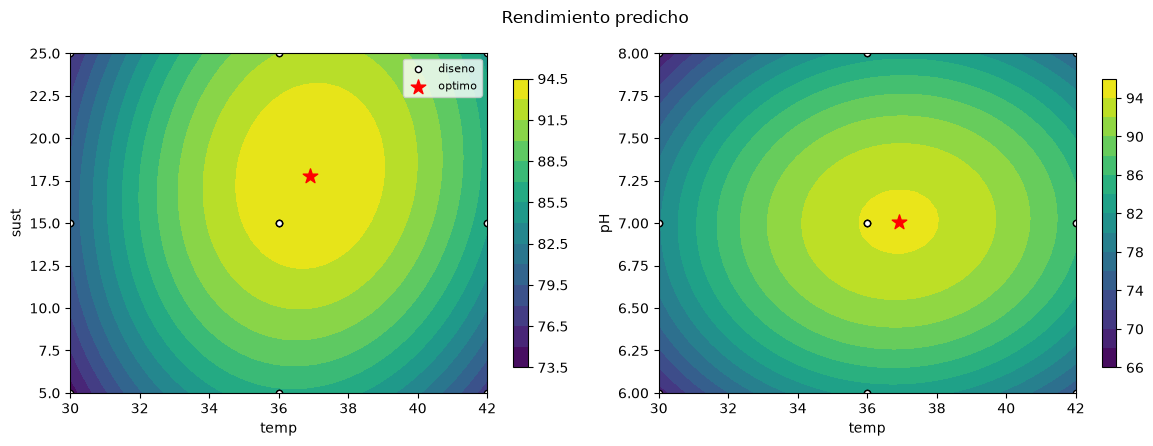

In [6]:
def predict(grid_df):
    return ed.fit_linear_model(bb, y).coef @ bb.model.matrix(grid_df).T

def contour(ax, fa, fb, fixed):
    ga = np.linspace(*factors[fa], 40)
    gb = np.linspace(*factors[fb], 40)
    GA, GB = np.meshgrid(ga, gb)
    df = pd.DataFrame({fa: GA.ravel(), fb: GB.ravel()})
    for k, v in fixed.items():
        df[k] = v
    Z = predict(df[names]).reshape(GA.shape)
    cs = ax.contourf(GA, GB, Z, levels=15, cmap="viridis")
    ax.scatter(m[fa], m[fb], c="white", s=20, edgecolor="black", label="diseno")
    ax.scatter([opt[fa]], [opt[fb]], c="red", s=120, marker="*", label="optimo")
    ax.set_xlabel(fa); ax.set_ylabel(fb)
    ax.figure.colorbar(cs, ax=ax, shrink=0.85)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
contour(axes[0], "temp", "sust", {"pH": opt["pH"]})
contour(axes[1], "temp", "pH", {"sust": opt["sust"]})
axes[0].legend(loc="upper right", fontsize=8)
plt.suptitle("Rendimiento predicho"); plt.tight_layout(); plt.show()

## 6. Box-Behnken vs Central Composite

Para el mismo problema, un **Central Composite** (CCD) agrega puntos axiales que permiten
estimar mejor la curvatura pura, a costa de mas corridas y de explorar fuera del cubo
`[-1, 1]` (con `alpha > 1`). La eleccion depende de si esas condiciones extremas son
alcanzables.

In [7]:
cc = ed.central_composite(factors, alpha="rotatable")
pd.DataFrame({
    "diseno": ["Box-Behnken", "Central Composite (rotatable)"],
    "corridas": [bb.n_runs, cc.n_runs],
    "alpha": ["-", round(cc.metadata["alpha_value"], 3)],
})

,diseno,corridas,alpha
0,Box-Behnken,15,-
1,Central Composite (rotatable),22,1.682


**Conclusion.** El modelo cuadratico recupera el optimo real con buena precision y R^2
alto. Las condiciones recomendadas salen de `x_star`. En un proyecto real, el siguiente
paso seria una corrida de confirmacion en ese punto.

## Evaluación y comparación de diseños (nuevo en doekit)

¿Box-Behnken o Central Composite? Los comparamos por D-eficiencia y por el FDS
plot (varianza de predicción sobre la región).

Box-Behnken        corridas=15  D-eff=36.6%  G-eff=51.7%
Central Composite  corridas=22  D-eff=63.8%  G-eff=75.4%


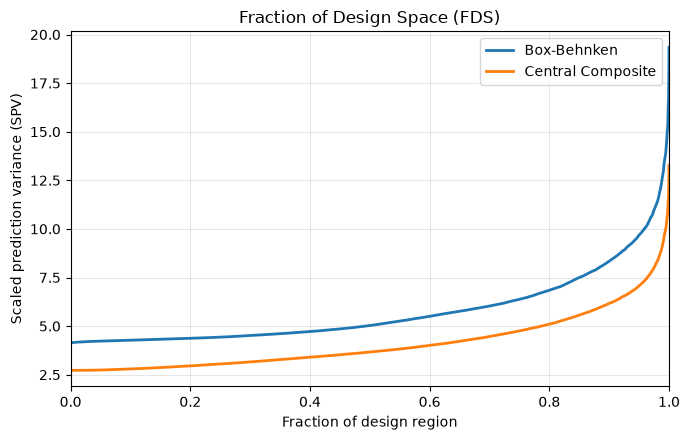

In [8]:
import doekit as ed
from doekit import plotting
import matplotlib.pyplot as plt

act = {"temp": (20,80), "ph": (3,9), "conc": (0.1,0.5)}
bb = ed.box_behnken(act, center=3); cc = ed.central_composite(act)
mq = ed.Model.full_quadratic(list(act))
for nombre,d in [("Box-Behnken",bb),("Central Composite",cc)]:
    e = ed.efficiencies(d, model=mq, seed=0)
    print("%-18s corridas=%2d  D-eff=%.1f%%  G-eff=%.1f%%" %
          (nombre, d.n_runs, e["D_efficiency"], e["G_efficiency"]))

fig, ax = plt.subplots(figsize=(7,4.5))
plotting.fds_plot(bb, model=mq, ax=ax, label="Box-Behnken", seed=0)
plotting.fds_plot(cc, model=mq, ax=ax, label="Central Composite", seed=0)
plt.tight_layout(); plt.show()


## Puente: falta de ajuste + hoja de corridas

Con centros replicados, `lack_of_fit` separa error puro vs falta de ajuste del modelo cuadrático.
`Experiment` empaqueta plan → ingest (y opcionalmente `next` para más corridas).


In [9]:
lof = ed.lack_of_fit(bb, y)
print(lof)

exp = ed.Experiment.from_design(bb, responses=["rendimiento"])
exp.ingest(y)
print(exp.plan.head())
print("R²:", round(exp.fit.r_squared, 4))
# opc.: nxt = exp.next(n_add=4); print(nxt.comparison.summary)


        source  df        ss        ms          F   p_value
0  lack_of_fit   3  4.251061  1.417020  19.315752  0.049624
1   pure_error   2  0.146722  0.073361        NaN       NaN
2     residual   5  4.397782  0.879556        NaN       NaN


   run_id  temp   ph  conc rendimiento
0       1  20.0  3.0   0.3        <NA>
1       2  80.0  3.0   0.3        <NA>
2       3  20.0  9.0   0.3        <NA>
3       4  80.0  9.0   0.3        <NA>
4       5  20.0  6.0   0.1        <NA>
R²: 0.9958


## Reporte del experimento (guía semántica)

El cierre de todo DoE es el **reporte**: qué se hizo, qué tan bueno fue el diseño, qué observar y qué concluir. Generamos el reporte en carpeta (`index.html` + CSS/imágenes/datos; o `self_contained=True` para un único HTML) y mostramos su **guía semántica inline** para validar que coincide con lo que el análisis de arriba mostró.

In [10]:
rep = ed.report(bb, response=y, output_dir="reports/02_rsm", title="Superficie de respuesta",
                lang="es")
guide = ed.report_summary(bb, response=y)

print("METODOLOGIA\n ", guide["methodology"], "\n")
print("RESUMEN EJECUTIVO")
for b in guide["executive_summary"]:
    print("  -", b)
print("\nRECOMENDACIONES (que accionar / que observar)")
for r in guide["recommendations"]:
    print("  ->", r)
an = guide["anomalies"]
if an is not None and len(an):
    print("\nVALORES ANOMALOS (corridas a revisar):")
    print(an.to_string(index=False))
print("\nReporte (carpeta index.html + assets) en:", rep)


METODOLOGIA
  Box-Behnken design: efficient response surface without points at the cube vertices. Center points: 3. 

RESUMEN EJECUTIVO
  - Design quality: D-efficiency 37% (typical of a standard RSM), G-efficiency 51%.
  - Significant terms: temp, ph, conc, temp:conc, temp^2, ph^2, conc^2. R2=0.996 (adjusted 0.988).

RECOMENDACIONES (que accionar / que observar)
  -> The relative D-efficiency (37%) is the one typical of a standard design for a quadratic model; it does not indicate a defect.
  -> Significant factors/terms (p<0.05): temp, ph, conc, temp:conc, temp^2, ph^2, conc^2.
  -> There are 2 atypical/influential run(s): review the anomalous-values section before concluding.

VALORES ANOMALOS (corridas a revisar):
 run               reason  studentized_resid  leverage  cooks_distance
   0 outlier, influential              4.271      0.75            1.23
   3 outlier, influential             -4.271      0.75            1.23

Reporte (carpeta index.html + assets) en: reports\02_rsm\i

## ¿Fue el diseño apropiado? (asesor de doekit)

Cierre: el asesor infiere el escenario de lo ejecutado y recomienda el método más apropiado, comparándolo con lo que hicimos — una recomendación coherente con el experimento. El 'mejor' es un trade-off (corridas vs precisión vs predicción); por eso se muestran las alternativas.

In [11]:
rec = guide["recommendation"]
if rec:
    print("DISENO EJECUTADO vs RECOMENDADO PARA ESTE CASO")
    print(" ", rec["note"])
    print()
    print(rec["table"].to_string(index=False))
else:
    print("(sin recomendacion: el diseno no tiene modelo asociado)")


DISENO EJECUTADO vs RECOMENDADO PARA ESTE CASO
  For this case (optimization, 3 factors, model 'quadratic', budget 15), the more efficient design would be D-optimal; you ran Box-Behnken. This is informative, not an error: review the alternatives table and choose by your priorities.

              method  runs  D_eff  G_eff  SPV_mean  in_budget  supports_model
         Box-Behnken    15   36.6   52.2      5.83       True            True
   Central Composite    22   63.8   79.0      4.12      False            True
Definitive Screening     9    NaN    NaN       NaN       True           False
           D-optimal    13   46.1   82.3      7.26       True            True
